# Employee burnout and productivity — a second analysis

This notebook redoes the analysis from the raw data, with the method chosen and defended in the
open rather than assumed. It is written as a working analyst would hand it over: every choice is
stated, every claim is checked, and the checks that overturned an earlier conclusion are kept in
the record instead of being quietly removed.

**Four things make this version different from the first pass:**

1. Candidate methods are compared and scored before any model is fitted.
2. A practical-significance threshold is applied on top of statistical significance, because at
   4.6 million rows almost every coefficient is "significant".
3. The number of groups is chosen against **two** stability tests, not one. The second test
   changed the answer.
4. A verification loop was run until the results stopped changing. Section 9 lists what it found,
   including three conclusions that had to be corrected.

**The data is synthetic** (a public Kaggle dataset). Treat every number as a demonstration of the
method, not as a finding about a real workforce.

In [1]:
import os
import sys
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score, r2_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd().parent / "src"))
import config as C
import plotting as P

P.setup_style()
HERE = Path.cwd()
FIG, TAB = HERE / "figures", HERE / "tables"
FIG.mkdir(exist_ok=True), TAB.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", pad_inches=0.25)

NROWS = int(os.environ["NB_NROWS"]) if os.environ.get("NB_NROWS") else None
SEED = 42
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
print(f"pandas {pd.__version__} · numpy {np.__version__} · statsmodels {sm.__version__}")

pandas 3.0.5 · numpy 2.4.6 · statsmodels 0.15.0


## 1. What is in the data

The first job is to find out what we have been handed, before deciding what to do with it.

In [2]:
t0 = time.time()
df = C.load_raw(nrows=NROWS)
print(f"Loaded in {time.time() - t0:.0f}s")
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}   Memory: {C.describe_memory(df)}")
print(f"Duplicate employee ids: {df['user_id'].duplicated().sum()}")

Loaded in 8s
Rows: 5,000,000   Columns: 34   Memory: 0.55 GB
Duplicate employee ids: 0


In [3]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "distinct_values": df.nunique(),
    "missing": df.isna().sum(),
})
schema["missing_%"] = (schema["missing"] / len(df) * 100).round(2)
print(schema.to_string())

                            dtype  distinct_values  missing  missing_%
user_id                     int32          5000000        0        0.0
age                         int16               42        0        0.0
occupation               category                7        0        0.0
work_mode                category                3        0        0.0
device_usage_type        category                3        0        0.0
daily_screen_time         float32              171        0        0.0
social_media_hours        float32              121   100000        2.0
doomscrolling_duration    float32               80        0        0.0
app_switch_frequency      float32              240        0        0.0
notification_count        float32              380        0        0.0
smartphone_unlocks        float32              285        0        0.0
late_night_device_usage   float32                2        0        0.0
focus_sessions            float32               10        0        0.0
deep_w

### 1.1 Missing values are injected, not accidental

Four columns are missing exactly 2% of their values each. If those 2% are drawn independently per
column, the share of rows missing *at least one* of the four should be `1 - 0.98**4 = 7.76%`.
That is what we see, to two decimal places — so the gaps are random by construction, not a
symptom of how the data was collected.

In [4]:
miss_cols = ["social_media_hours", "deep_work_hours", "sleep_hours", "motivation_level"]
any_missing = df[miss_cols].isna().any(axis=1)
print(f"Rows missing at least one of the four : {any_missing.sum():,} ({any_missing.mean()*100:.2f}%)")
print(f"Expected if independent at 2% each    : {(1 - 0.98**4)*100:.2f}%")
print("\nOutcome means, rows with a gap vs rows without:")
print(df.groupby(any_missing)[["burnout_risk", "productivity_score"]].mean().round(2).to_string())
print("\nThe two rows are the same, so dropping incomplete rows does not bias the outcomes.")

Rows missing at least one of the four : 387,938 (7.76%)
Expected if independent at 2% each    : 7.76%

Outcome means, rows with a gap vs rows without:
       burnout_risk  productivity_score
False     48.580002           71.449997
True      48.580002           71.400002

The two rows are the same, so dropping incomplete rows does not bias the outcomes.


### 1.2 The 25 behavioural inputs are independent of each other

This single fact shapes every method choice that follows, so it is worth establishing first.

In [5]:
fc = df[C.CLUSTER_FEATURES].corr().to_numpy().copy()
np.fill_diagonal(fc, 0)
print(f"Largest absolute correlation between any two behavioural inputs: {np.abs(fc).max():.4f}")
print("\nFor comparison, real survey data would show correlated blocks here (for example, people who")
print("sleep badly also tend to report more stress). This dataset has none of that structure.")

Largest absolute correlation between any two behavioural inputs: 0.0012

For comparison, real survey data would show correlated blocks here (for example, people who
sleep badly also tend to report more stress). This dataset has none of that structure.


### 1.3 But the inputs do relate to the two outcomes

In [6]:
corr_tbl = pd.concat([
    df[C.CLUSTER_FEATURES].corrwith(df["burnout_risk"]).rename("vs_burnout"),
    df[C.CLUSTER_FEATURES].corrwith(df["productivity_score"]).rename("vs_productivity"),
], axis=1)
corr_tbl.index = [C.LABELS.get(i, i) for i in corr_tbl.index]
print(corr_tbl.reindex(corr_tbl.abs().max(axis=1).sort_values(ascending=False).index).round(3).to_string())

                                            vs_burnout  vs_productivity
Deep work (h/day)                               -0.047            0.560
Emotional exhaustion (1-10)                      0.512           -0.182
Stress (1-10)                                    0.383           -0.135
Task completion rate (%)                         0.000            0.356
Concentration (1-10)                            -0.000            0.347
Job satisfaction (1-10)                         -0.254            0.091
Motivation (1-10)                                0.000            0.231
Focus sessions per day                           0.001            0.230
Screen time (h/day)                              0.221           -0.078
Doomscrolling (h/day)                            0.200           -0.072
Workspace quality (1-10)                         0.000            0.172
Late-night device use (0/1)                      0.158           -0.056
Distractions per day                             0.152          

### 1.4 Two columns are labels, not inputs

`productivity_category` turns out to be a plain binning of `productivity_score` — the ranges do not
overlap at all, so it carries no information of its own. `mental_state` is different: its burnout
ranges overlap completely, so it is *not* a binning, though it does track burnout on average.

Either way, both are outcome-side labels. Using them to predict the outcomes would be circular, so
both are excluded from every model below.

In [7]:
print("productivity_category vs productivity_score:")
print(df.groupby("productivity_category", observed=True)["productivity_score"]
        .agg(["min", "max"]).to_string())
print("\nmental_state vs burnout_risk:")
print(df.groupby("mental_state", observed=True)["burnout_risk"]
        .agg(["min", "max", "mean"]).round(1).to_string())

productivity_category vs productivity_score:
                        min    max
productivity_category             
High                   75.0  100.0
Low                     0.0   49.0
Medium                 50.0   74.0

mental_state vs burnout_risk:
              min    max       mean
mental_state                       
Balanced      0.0  100.0  48.099998
Burnout       0.0  100.0  62.799999
Distracted    0.0  100.0  48.099998
Focused       0.0  100.0  38.299999


## 2. Choosing a method, before fitting anything

Four analytical questions follow from section 1, and each has more than one reasonable method.
The tables below score the candidates 1–5 on five criteria.

**These scores are the analyst's judgement, not measurements.** They are written down so the
reasoning can be argued with, not to give the choice a false air of precision.

### Question A — which habits actually move the outcomes?

| Method | Fits the data | Explainable | Feasible at 5M | Actionable | Verifiable | Total |
|---|:-:|:-:|:-:|:-:|:-:|:-:|
| Correlation only | 4 | 5 | 5 | 2 | 3 | 19 |
| **Multiple linear regression (OLS)** | **5** | **4** | **5** | **5** | **5** | **24** |
| Ridge / Lasso | 3 | 3 | 5 | 3 | 4 | 18 |
| Gradient boosting | 3 | 2 | 3 | 3 | 4 | 15 |

OLS wins mainly *because* of section 1.2: with independent inputs there is no multicollinearity,
which is the usual reason to reach for a regularised or tree-based model. Its coefficients convert
straight into "one more hour of X goes with Y more points", which is what a recommendation needs.
Gradient boosting is kept as a cross-check on whether the straight-line assumption holds.

### Question B — can employees be grouped usefully?

| Method | Fits the data | Explainable | Feasible at 5M | Actionable | Verifiable | Total |
|---|:-:|:-:|:-:|:-:|:-:|:-:|
| K-Means, all 25 inputs equally weighted | 1 | 4 | 5 | 3 | 1 | 14 |
| **K-Means, weighted by link to outcomes** | **4** | **4** | **5** | **5** | **4** | **22** |
| Gaussian mixture | 3 | 2 | 3 | 3 | 4 | 15 |
| Hierarchical (Ward) | 3 | 3 | 2 | 3 | 3 | 14 |
| Threshold rules | 3 | 5 | 5 | 4 | 2 | 19 |

Equal weighting scores 1 on "fits the data" because, with independent inputs, most of the 25
dimensions are noise as far as the outcomes are concerned; a distance built on all of them equally
would be mostly noise. Weighting by the link to the outcomes is the fix.

### Question C — does job context matter?

One-way ANOVA with eta-squared, because it produces a number ("context explains X% of the
variation") rather than an impression from a table of means.

### Considered and rejected

**PCA.** Its purpose is to compress correlated variables. Section 1.2 shows the inputs are not
correlated, so each component would be little more than a single original variable wearing a
disguise — all of the interpretability lost, none of the compression gained.

## 3. Preparing the modelling table

### 3.1 Job context is formally ruled out

In [8]:
model_df = df.dropna(subset=miss_cols).copy()
print(f"Complete-case rows: {len(model_df):,} ({len(model_df)/len(df)*100:.1f}% of the raw data)\n")

rows = []
for col in ["occupation", "work_mode", "device_usage_type"]:
    for outcome in C.OUTCOMES:
        groups = [g[outcome].to_numpy() for _, g in model_df.groupby(col, observed=True)]
        f_stat, p_val = stats.f_oneway(*groups)
        k, n = len(groups), len(model_df)
        eta2 = (f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k))
        rows.append({"context": col, "outcome": outcome, "eta_squared": eta2,
                     "F": f_stat, "p_value": p_val})
anova = pd.DataFrame(rows)
print(anova.round(5).to_string(index=False))
print("\nEta-squared is zero to five decimal places everywhere: occupation, work mode and device")
print("type explain none of the variation in either outcome. They are kept for filtering and")
print("reporting, and excluded from every model.")
anova.to_csv(TAB / "01_context_anova.csv", index=False)

Complete-case rows: 4,612,062 (92.2% of the raw data)



          context            outcome  eta_squared       F  p_value
       occupation       burnout_risk          0.0 0.33293  0.91992
       occupation productivity_score          0.0 0.71374  0.63852
        work_mode       burnout_risk          0.0 0.07171  0.93080
        work_mode productivity_score          0.0 0.70026  0.49646
device_usage_type       burnout_risk          0.0 0.45806  0.63251
device_usage_type productivity_score          0.0 1.01442  0.36261

Eta-squared is zero to five decimal places everywhere: occupation, work mode and device
type explain none of the variation in either outcome. They are kept for filtering and
reporting, and excluded from every model.


## 4. Which habits move the outcomes

Two regressions, one per outcome, on the 25 behavioural inputs. Coefficients are reported in two
forms: standardised (comparable across variables) and raw units (readable as advice).

In [9]:
PRED = C.CLUSTER_FEATURES
X = model_df[PRED].astype("float64")
Xz = sm.add_constant((X - X.mean()) / X.std())

models, betas = {}, {}
for outcome in C.OUTCOMES:
    y = model_df[outcome].astype("float64")
    fit = sm.OLS((y - y.mean()) / y.std(), Xz).fit()
    models[outcome] = fit
    betas[outcome] = fit.params.drop("const")
    print(f"{outcome:20s} R² = {fit.rsquared:.4f}   n = {int(fit.nobs):,}")

burnout_risk         R² = 0.6509   n = 4,612,062


productivity_score   R² = 0.8057   n = 4,612,062


### 4.1 Statistical significance is not enough here

With 4.6 million rows, a coefficient of 0.0006 comes out "statistically significant". That is a
statement about sample size, not about importance. So a second, practical bar is added:
a standardised coefficient of at least 0.05 in absolute value.

In [10]:
PRACTICAL = 0.05
drivers = pd.DataFrame({
    "beta_burnout": betas["burnout_risk"],
    "p_burnout": models["burnout_risk"].pvalues.drop("const"),
    "beta_productivity": betas["productivity_score"],
    "p_productivity": models["productivity_score"].pvalues.drop("const"),
})
drivers["matters_for"] = np.select(
    [(drivers["beta_burnout"].abs() >= PRACTICAL) & (drivers["beta_productivity"].abs() >= PRACTICAL),
     drivers["beta_burnout"].abs() >= PRACTICAL,
     drivers["beta_productivity"].abs() >= PRACTICAL],
    ["both", "burnout", "productivity"], default="neither")
drivers.index = [C.LABELS.get(i, i) for i in drivers.index]
drivers = drivers.reindex(drivers[["beta_burnout", "beta_productivity"]].abs().max(axis=1)
                          .sort_values(ascending=False).index)
print(drivers.round(4).to_string())

n_sig = (drivers[["p_burnout", "p_productivity"]] < 0.05).any(axis=1).sum()
n_real = (drivers["matters_for"] != "neither").sum()
print(f"\nStatistically significant for at least one outcome : {n_sig} of 25")
print(f"Also clearing the practical bar                    : {n_real} of 25")
drivers.to_csv(TAB / "02_drivers.csv")

                                            beta_burnout  p_burnout  beta_productivity  p_productivity   matters_for
Deep work (h/day)                                -0.0468     0.0000             0.5602          0.0000  productivity
Emotional exhaustion (1-10)                       0.5113     0.0000            -0.1814          0.0000          both
Stress (1-10)                                     0.3827     0.0000            -0.1358          0.0000          both
Task completion rate (%)                         -0.0001     0.8029             0.3555          0.0000  productivity
Concentration (1-10)                              0.0002     0.5132             0.3477          0.0000  productivity
Job satisfaction (1-10)                          -0.2544     0.0000             0.0903          0.0000          both
Motivation (1-10)                                 0.0003     0.2649             0.2309          0.0000  productivity
Focus sessions per day                            0.0006     0.0

### 4.2 Is the straight-line assumption safe?

Gradient boosting can fit curves and interactions that OLS cannot. If it barely beats OLS on
held-out data, the relationships really are close to straight lines and the simpler, explainable
model is the right one to ship.

In [11]:
sample = model_df.sample(n=min(500_000, len(model_df)), random_state=SEED)
Xs = sample[PRED].astype("float64")
for outcome in C.OUTCOMES:
    ys = sample[outcome].astype("float64")
    X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.25, random_state=SEED)
    r2_ols = r2_score(y_te, LinearRegression().fit(X_tr, y_tr).predict(X_te))
    gbm = HistGradientBoostingRegressor(random_state=SEED, max_depth=6, max_iter=200).fit(X_tr, y_tr)
    r2_gbm = r2_score(y_te, gbm.predict(X_te))
    print(f"{outcome:20s} OLS {r2_ols:.4f}   gradient boosting {r2_gbm:.4f}   gap {r2_gbm-r2_ols:+.4f}")
print("\nThe gap is small, so the straight-line model is keeping up. OLS it is.")

burnout_risk         OLS 0.6523   gradient boosting 0.6515   gap -0.0007


productivity_score   OLS 0.8056   gradient boosting 0.8259   gap +0.0204

The gap is small, so the straight-line model is keeping up. OLS it is.


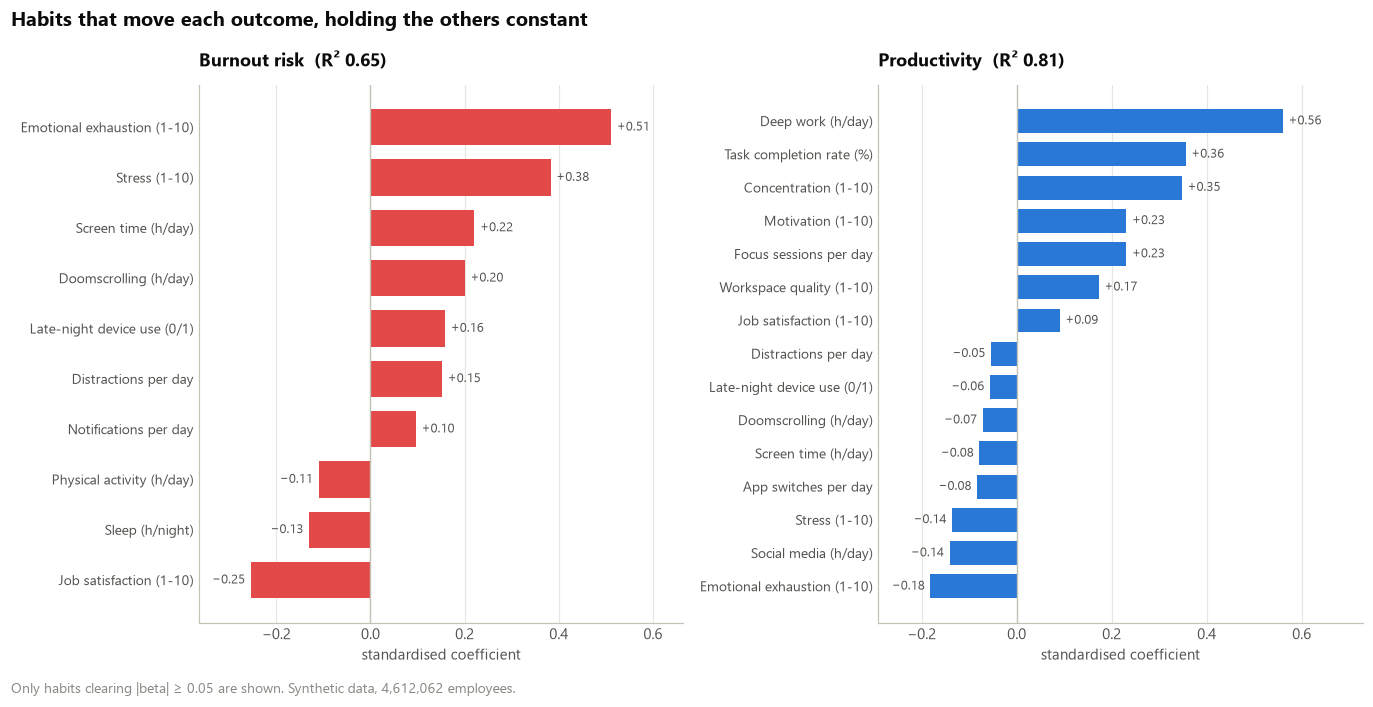

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.2), sharey=False)
for ax, outcome, colour in zip(axes, C.OUTCOMES, [P.RED, P.BLUE]):
    key = "beta_burnout" if outcome == "burnout_risk" else "beta_productivity"
    d = drivers[drivers[key].abs() >= PRACTICAL][key].sort_values()
    bars = ax.barh(range(len(d)), d.values, color=colour, height=0.72)
    for i, v in enumerate(d.values):
        ax.text(v + (0.012 if v >= 0 else -0.012), i, P.num(v, 2, signed=True),
                va="center", ha="left" if v >= 0 else "right", fontsize=8.5, color=P.INK_2)
    ax.set_yticks(range(len(d)), d.index, fontsize=9)
    ax.axvline(0, color=P.AXIS, lw=0.9)
    # room on the left for value labels on negative bars, so they clear the category names
    ax.set_xlim(min(d.min() - 0.11, -0.16), max(d.max() * 1.3, 0.12))
    ax.set_title(f"{'Burnout risk' if outcome == 'burnout_risk' else 'Productivity'}"
                 f"  (R² {models[outcome].rsquared:.2f})")
    ax.set_xlabel("standardised coefficient")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
fig.suptitle("Habits that move each outcome, holding the others constant",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.text(0.005, -0.02, f"Only habits clearing |beta| ≥ {PRACTICAL} are shown. "
                       f"Synthetic data, {len(model_df):,} employees.",
         fontsize=9, color=P.MUTED)
fig.tight_layout()
save_fig(fig, "01_drivers")
plt.show()

## 5. Grouping the employees

### 5.1 Weights come from the regression, not from a guess

Each habit is weighted by how strongly it moves the outcomes, normalised so that the two outcomes
contribute on the same scale. Habits that cleared neither practical bar get no weight at all —
they are dropped rather than quietly down-weighted.

In [13]:
real_drivers = sorted(set(betas["burnout_risk"][betas["burnout_risk"].abs() >= PRACTICAL].index) |
                      set(betas["productivity_score"][betas["productivity_score"].abs() >= PRACTICAL].index))
w = ((betas["burnout_risk"].abs() / betas["burnout_risk"].abs().max()) +
     (betas["productivity_score"].abs() / betas["productivity_score"].abs().max())).loc[real_drivers]
print(f"Habits used for grouping: {len(real_drivers)} of 25\n")
print(w.rename(index=C.LABELS).sort_values(ascending=False).round(3).to_string())
print(f"\nDropped as noise: {', '.join(C.LABELS.get(c, c) for c in PRED if c not in real_drivers)}")

Z = (model_df[real_drivers] - model_df[real_drivers].mean()) / model_df[real_drivers].std()
Xw = (Z * w).to_numpy(dtype="float32")

Habits used for grouping: 18 of 25

Emotional exhaustion (1-10)    1.324
Deep work (h/day)              1.092
Stress (1-10)                  0.991
Job satisfaction (1-10)        0.659
Task completion rate (%)       0.635
Concentration (1-10)           0.621
Screen time (h/day)            0.572
Doomscrolling (h/day)          0.519
Focus sessions per day         0.413
Motivation (1-10)              0.413
Late-night device use (0/1)    0.410
Distractions per day           0.394
Sleep (h/night)                0.338
Workspace quality (1-10)       0.309
Physical activity (h/day)      0.286
Social media (h/day)           0.253
Notifications per day          0.250
App switches per day           0.149

Dropped as noise: Phone unlocks per day, Meetings (h/day), Sleep quality (1-10), Caffeine intake (per day, unit not stated), Internet stability (1-10), Remote days per week, Mental fatigue (1-10)


### 5.2 How many groups? Two stability tests, not one

The obvious test is to re-run K-Means with different random seeds on the same data and see whether
the groupings agree (Adjusted Rand Index, 1.0 = identical). That test alone is **not sufficient**,
and believing it cost this analysis a wrong answer on the first pass.

A second test is needed: fit on genuinely different subsets of employees and check whether the
groupings still agree. A value of k can be perfectly reproducible on one fixed dataset and still
fall apart when the data changes underneath it.

In [14]:
rs = np.random.RandomState(7)
SUB_N = min(400_000, len(Xw) // 3)
subsets = [rs.choice(len(Xw), SUB_N, replace=False) for _ in range(3)]
eval_idx = rs.choice(len(Xw), SUB_N, replace=False)
X_eval = Xw[eval_idx]
b_eval = model_df["burnout_risk"].to_numpy("float64")[eval_idx]
p_eval = model_df["productivity_score"].to_numpy("float64")[eval_idx]

def eta_squared(labels, values):
    grand = values.mean()
    grouped = pd.Series(values).groupby(np.asarray(labels))
    return sum(len(g) * (g.mean() - grand) ** 2 for _, g in grouped) / ((values - grand) ** 2).sum()

rows = []
for k in [5, 6, 7, 8, 9]:
    seeds = [KMeans(n_clusters=k, n_init=10, random_state=s).fit(Xw[subsets[0]]).labels_ for s in range(3)]
    ari_seed = np.mean([adjusted_rand_score(a, b) for a, b in itertools.combinations(seeds, 2)])
    fits = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xw[i]) for i in subsets]
    across = [f.predict(X_eval) for f in fits]
    ari_data = np.mean([adjusted_rand_score(a, b) for a, b in itertools.combinations(across, 2)])
    labels = fits[0].predict(X_eval)
    rows.append({"k": k, "ari_across_seeds": ari_seed, "ari_across_datasets": ari_data,
                 "eta2_burnout": eta_squared(labels, b_eval),
                 "eta2_productivity": eta_squared(labels, p_eval)})
    print(f"k={k}  seeds {ari_seed:.3f}   datasets {ari_data:.3f}   "
          f"eta² {eta_squared(labels, b_eval):.3f} / {eta_squared(labels, p_eval):.3f}")

k_table = pd.DataFrame(rows).set_index("k")
k_table.to_csv(TAB / "03_k_selection.csv")
best_k = int(k_table["ari_across_datasets"].idxmax())
print(f"\nMost stable across datasets: k = {best_k}")

k=5  seeds 0.988   datasets 0.617   eta² 0.247 / 0.224


k=6  seeds 0.972   datasets 0.467   eta² 0.297 / 0.214


k=7  seeds 0.743   datasets 0.742   eta² 0.300 / 0.240


k=8  seeds 0.983   datasets 0.976   eta² 0.311 / 0.254


k=9  seeds 0.673   datasets 0.714   eta² 0.325 / 0.251

Most stable across datasets: k = 8


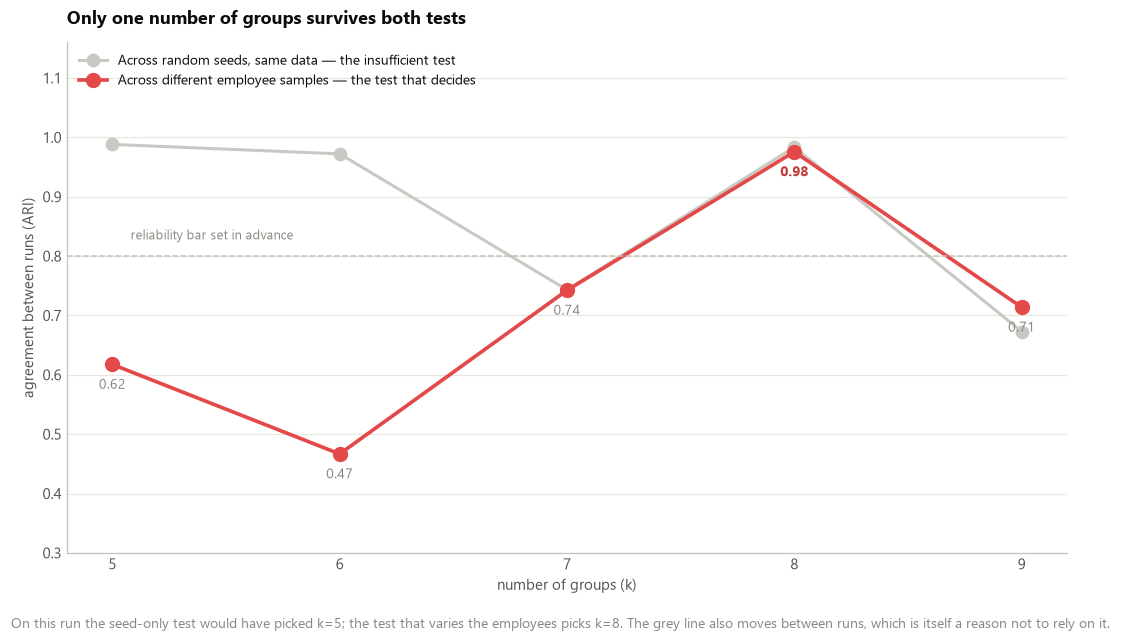

In [15]:
seed_pick = int(k_table["ari_across_seeds"].idxmax())

fig, ax = plt.subplots(figsize=(9.8, 5.6))
ax.plot(k_table.index, k_table["ari_across_seeds"], "o-", color=P.DEEMPH, lw=2,
        markersize=8, label="Across random seeds, same data — the insufficient test")
ax.plot(k_table.index, k_table["ari_across_datasets"], "o-", color=P.RED, lw=2.4,
        markersize=9, label="Across different employee samples — the test that decides")
for k_, v in k_table["ari_across_datasets"].items():
    ax.annotate(P.num(v, 2), (k_, v), textcoords="offset points", xytext=(0, -16),
                ha="center", fontsize=9,
                color=P.WORSE if k_ == best_k else P.MUTED,
                fontweight="bold" if k_ == best_k else "normal")
ax.axhline(0.8, color=P.AXIS, ls="--", lw=1)
ax.text(k_table.index.min() + 0.08, 0.828, "reliability bar set in advance",
        fontsize=8.5, color=P.MUTED, ha="left")
ax.set_xticks(list(k_table.index))
ax.set_ylim(0.30, 1.16)
ax.set_xlabel("number of groups (k)")
ax.set_ylabel("agreement between runs (ARI)")
ax.set_title("Only one number of groups survives both tests")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.0))
fig.text(0.005, -0.03,
         f"On this run the seed-only test would have picked k={seed_pick}; the test that varies the "
         f"employees picks k={best_k}. The grey line also moves between runs, which is itself a "
         f"reason not to rely on it.", fontsize=9, color=P.MUTED)
fig.tight_layout()
save_fig(fig, "02_k_selection")
plt.show()

### 5.3 What the groups are actually made of

In [16]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xw)
profile = (model_df.assign(cluster=km.labels_)
           .groupby("cluster")
           .agg(share_pct=("burnout_risk", lambda s: len(s) / len(model_df) * 100),
                exhaustion=("emotional_exhaustion", "mean"),
                stress=("stress_level", "mean"),
                deep_work=("deep_work_hours", "mean"),
                burnout=("burnout_risk", "mean"),
                productivity=("productivity_score", "mean"))
           .sort_values("burnout", ascending=False))
print(profile.round(2).to_string())
print("\nThe groups separate on exactly three habits, each taking one of two levels — a 2×2×2 grid.")
print("The other 15 habits are the same in every group, which is what section 1.2 predicted.")

         share_pct  exhaustion  stress  deep_work    burnout  productivity
cluster                                                                   
4            12.80         8.0     8.0       1.67  66.389999     55.060001
2            12.23         8.0     8.0       4.47  65.169998     76.279999
3            13.36         8.0     3.0       1.72  51.680000     61.209999
6            11.67         8.0     3.0       4.53  50.299999     81.480003
5            13.31         3.0     8.0       1.73  46.709999     63.169998
0            11.65         3.0     8.0       4.53  45.389999     82.959999
1            12.75         3.0     3.0       1.66  31.969999     68.300003
7            12.23         3.0     3.0       4.47  30.770000     86.690002

The groups separate on exactly three habits, each taking one of two levels — a 2×2×2 grid.
The other 15 habits are the same in every group, which is what section 1.2 predicted.


In [17]:
spread = ((model_df.assign(cluster=km.labels_).groupby("cluster")[real_drivers].mean().max() -
           model_df.assign(cluster=km.labels_).groupby("cluster")[real_drivers].mean().min())
          / model_df[real_drivers].std()).sort_values(ascending=False)
spread.index = [C.LABELS.get(i, i) for i in spread.index]
print("How far each habit spreads across the groups, in standard deviations:\n")
print(spread.round(3).to_string())
print("\nThree habits do all the separating. Everything below them is flat, so no group can be")
print("told to 'sleep more' or 'scroll less' on the evidence that its group sleeps less or scrolls")
print("more — none of them do. Those remain company-wide actions.")
spread.to_frame("spread_in_sd").to_csv(TAB / "04_habit_spread.csv")

How far each habit spreads across the groups, in standard deviations:

Stress (1-10)                  1.742
Emotional exhaustion (1-10)    1.741
Deep work (h/day)              1.664
Physical activity (h/day)      0.006
App switches per day           0.005
Task completion rate (%)       0.005
Screen time (h/day)            0.005
Concentration (1-10)           0.004
Social media (h/day)           0.004
Distractions per day           0.004
Focus sessions per day         0.003
Doomscrolling (h/day)          0.003
Workspace quality (1-10)       0.003
Sleep (h/night)                0.003
Job satisfaction (1-10)        0.003
Motivation (1-10)              0.003
Notifications per day          0.003
Late-night device use (0/1)    0.002

Three habits do all the separating. Everything below them is flat, so no group can be
told to 'sleep more' or 'scroll less' on the evidence that its group sleeps less or scrolls
more — none of them do. Those remain company-wide actions.


### 5.4 Replacing the algorithm with a rule

The groups turn out to be a grid on three habits. That invites a question: if a plain rule —
split each of the three at its median — produces the same groups, it should be preferred. It is
deterministic, it needs no seed, and anyone can apply it by hand.

The cut points are the medians, chosen from the data's own distribution rather than read off the
cluster centres, so this is a fair comparison and not the rule being fitted to the answer.

In [18]:
cuts = {c: model_df[c].median() for c in ["emotional_exhaustion", "stress_level", "deep_work_hours"]}
print("Cut points (medians):", {k_: round(v, 2) for k_, v in cuts.items()})

level = lambda col: np.where(model_df[col] > cuts[col], "HIGH", "LOW")
model_df["grp_exhaustion"] = level("emotional_exhaustion")
model_df["grp_stress"] = level("stress_level")
model_df["grp_deepwork"] = level("deep_work_hours")
model_df["segment"] = ("Exhaustion " + model_df["grp_exhaustion"] +
                       " / Stress " + model_df["grp_stress"] +
                       " / Deep work " + model_df["grp_deepwork"])

b_all = model_df["burnout_risk"].to_numpy("float64")
p_all = model_df["productivity_score"].to_numpy("float64")
comparison = pd.DataFrame([
    {"method": f"K-Means (k={best_k})", "groups": best_k,
     "eta2_burnout": eta_squared(km.labels_, b_all),
     "eta2_productivity": eta_squared(km.labels_, p_all), "deterministic": "no"},
    {"method": "Median-split rule", "groups": model_df["segment"].nunique(),
     "eta2_burnout": eta_squared(model_df["segment"], b_all),
     "eta2_productivity": eta_squared(model_df["segment"], p_all), "deterministic": "yes"},
])
print("\n" + comparison.round(4).to_string(index=False))
print(f"\nAgreement between the two: ARI {adjusted_rand_score(km.labels_, model_df['segment']):.3f}")
print("\nThe rule gives up a little separation on burnout and none on productivity, in exchange for")
print("being reproducible by definition and explainable in one sentence. The clustering still did")
print("the work that mattered: it found which three habits, and how many groups, without being told.")
comparison.to_csv(TAB / "05_method_comparison.csv", index=False)

Cut points (medians): {'emotional_exhaustion': np.float32(6.0), 'stress_level': np.float32(5.0), 'deep_work_hours': np.float32(3.0)}



           method  groups  eta2_burnout  eta2_productivity deterministic
    K-Means (k=8)       8         0.311             0.2536            no
Median-split rule       8         0.303             0.2535           yes



Agreement between the two: ARI 0.777

The rule gives up a little separation on burnout and none on productivity, in exchange for
being reproducible by definition and explainable in one sentence. The clustering still did
the work that mattered: it found which three habits, and how many groups, without being told.


### 5.5 Cross-checks on the clustering

In [19]:
check_idx = np.random.RandomState(SEED).choice(len(Xw), min(50_000, len(Xw)), replace=False)
X_chk, lab_chk = Xw[check_idx], km.labels_[check_idx]
gmm = GaussianMixture(n_components=best_k, random_state=0, n_init=3).fit(X_chk)
print(f"Agreement with a Gaussian mixture : ARI {adjusted_rand_score(lab_chk, gmm.predict(X_chk)):.3f}")
sil = silhouette_score(X_chk[:20_000], lab_chk[:20_000])
print(f"Silhouette score                  : {sil:.3f}")
print("\nA low silhouette is the expected result, not a failure. It says there are no dense, naturally")
print("separated clusters here — which section 1.2 already implied. The groups are a useful way to")
print("divide a continuous population, not discovered 'types' of people.")

Agreement with a Gaussian mixture : ARI 0.453


Silhouette score                  : 0.088

A low silhouette is the expected result, not a failure. It says there are no dense, naturally
separated clusters here — which section 1.2 already implied. The groups are a useful way to
divide a continuous population, not discovered 'types' of people.


## 6. Ranking the groups by risk

### 6.1 Strong output must not cancel out high burnout

A risk score that averages burnout against productivity lets a high performer's output hide their
condition. The score used here adds only the harmful side of each measure, so good output can
never subtract from a burnout signal.

In [20]:
z_burn = (model_df["burnout_risk"] - model_df["burnout_risk"].mean()) / model_df["burnout_risk"].std()
z_prod = (model_df["productivity_score"] - model_df["productivity_score"].mean()) / model_df["productivity_score"].std()
model_df["risk"] = z_burn.clip(lower=0) + (-z_prod).clip(lower=0)
risk_compensating = z_burn - z_prod

high_burnout = model_df["burnout_risk"] >= 70
print(f"Employees with burnout risk 70 or above: {high_burnout.sum():,} ({high_burnout.mean()*100:.1f}%)\n")
print("How many of them a compensating score would leave out of the priority list:")
for q in [0.70, 0.80, 0.90, 0.95]:
    missed = (high_burnout & (model_df["risk"] >= model_df["risk"].quantile(q))
              & ~(risk_compensating >= risk_compensating.quantile(q)))
    print(f"  priority list = top {int((1-q)*100):>2}%  →  {missed.sum():>7,} missed "
          f"({missed.sum()/high_burnout.sum()*100:.1f}% of them)")

missed_20 = (high_burnout & (model_df["risk"] >= model_df["risk"].quantile(0.80))
             & ~(risk_compensating >= risk_compensating.quantile(0.80)))
if missed_20.sum():
    print(f"\nThe people missed at a top-20% list average burnout "
          f"{model_df.loc[missed_20, 'burnout_risk'].mean():.1f} and productivity "
          f"{model_df.loc[missed_20, 'productivity_score'].mean():.1f}.")
print("\nNote that the size of this effect depends on how wide the priority list is, and it")
print("disappears entirely at a narrow enough list. The choice of list width is a management")
print("decision, not something the data settles.")

Employees with burnout risk 70 or above: 825,089 (17.9%)

How many of them a compensating score would leave out of the priority list:


  priority list = top 30%  →   73,772 missed (8.9% of them)


  priority list = top 19%  →   35,292 missed (4.3% of them)


  priority list = top  9%  →    9,614 missed (1.2% of them)
  priority list = top  5%  →        0 missed (0.0% of them)



The people missed at a top-20% list average burnout 88.7 and productivity 89.4.

Note that the size of this effect depends on how wide the priority list is, and it
disappears entirely at a narrow enough list. The choice of list width is a management
decision, not something the data settles.


### 6.2 The eight groups, ranked

In [21]:
segments = (model_df.groupby("segment")
            .agg(share_pct=("risk", lambda s: len(s) / len(model_df) * 100),
                 burnout=("burnout_risk", "mean"),
                 productivity=("productivity_score", "mean"),
                 risk_score=("risk", "mean"))
            .sort_values("risk_score", ascending=False))
segments.insert(0, "rank", range(1, len(segments) + 1))
print(segments.round(2).to_string())
segments.to_csv(TAB / "06_segments.csv")

                                                rank  share_pct    burnout  productivity  risk_score
segment                                                                                             
Exhaustion HIGH / Stress HIGH / Deep work LOW      1      10.23  68.349998     54.270000        1.85
Exhaustion HIGH / Stress HIGH / Deep work HIGH     2       9.78  67.129997     75.639999        1.18
Exhaustion HIGH / Stress LOW / Deep work LOW       3      10.23  53.669998     60.000000        1.16
Exhaustion LOW / Stress HIGH / Deep work LOW       4      15.32  48.700001     61.959999        0.98
Exhaustion HIGH / Stress LOW / Deep work HIGH      5       9.77  52.330002     80.440002        0.60
Exhaustion LOW / Stress LOW / Deep work LOW        6      15.32  33.939999     67.540001        0.58
Exhaustion LOW / Stress HIGH / Deep work HIGH      7      14.66  47.430000     81.930000        0.48
Exhaustion LOW / Stress LOW / Deep work HIGH       8      14.69  32.740002     86.139999   

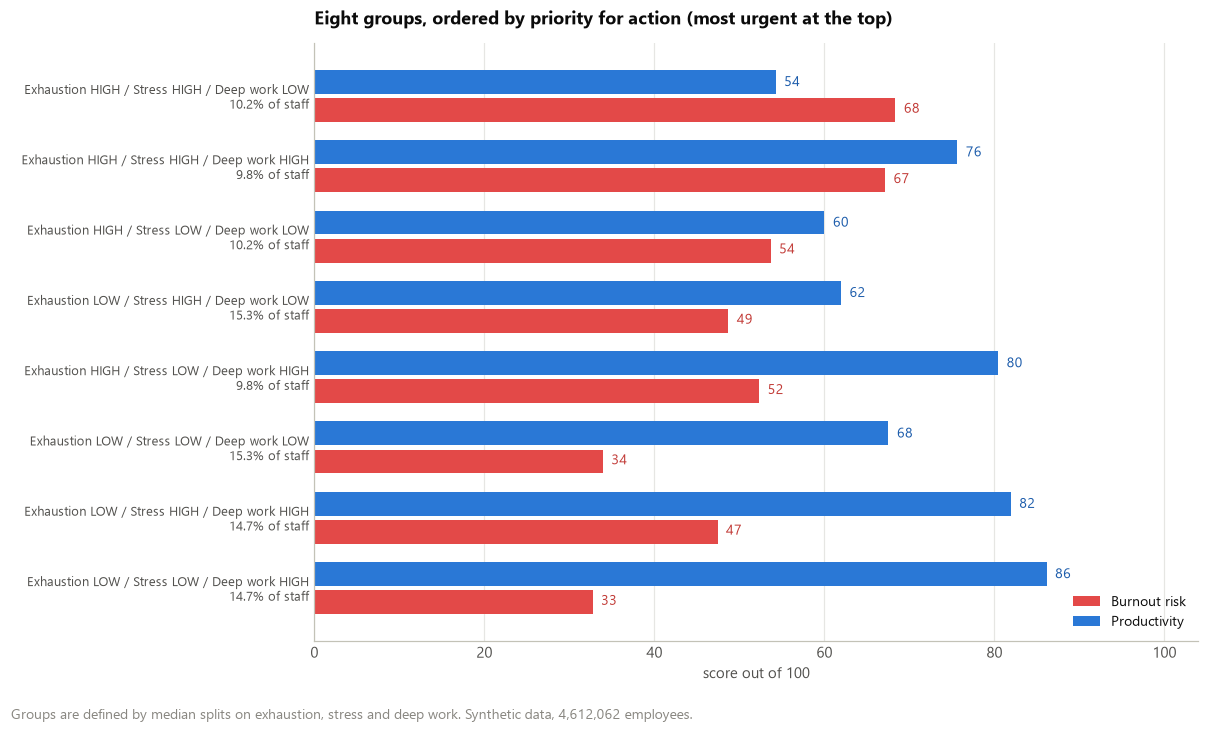

In [22]:
fig, ax = plt.subplots(figsize=(11, 6.4))
order = segments.index[::-1]
y = np.arange(len(order))
ax.barh(y - 0.20, segments.loc[order, "burnout"], height=0.34, color=P.RED, label="Burnout risk")
ax.barh(y + 0.20, segments.loc[order, "productivity"], height=0.34, color=P.BLUE, label="Productivity")
for i, seg in enumerate(order):
    ax.text(segments.loc[seg, "burnout"] + 1, i - 0.19, P.num(segments.loc[seg, "burnout"], 0),
            va="center", fontsize=9, color=P.WORSE)
    ax.text(segments.loc[seg, "productivity"] + 1, i + 0.19, P.num(segments.loc[seg, "productivity"], 0),
            va="center", fontsize=9, color=P.BETTER)
labels = [f"{s}\n{segments.loc[s, 'share_pct']:.1f}% of staff" for s in order]
ax.set_yticks(y, labels, fontsize=8.5)
ax.set_xlim(0, 104)
ax.set_xlabel("score out of 100")
ax.set_title("Eight groups, ordered by priority for action (most urgent at the top)")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right")   # sits in the empty space below the shortest bottom bar
fig.text(0.005, -0.03, "Groups are defined by median splits on exhaustion, stress and deep work. "
                       f"Synthetic data, {len(model_df):,} employees.", fontsize=9, color=P.MUTED)
fig.tight_layout()
save_fig(fig, "03_segments")
plt.show()

## 7. What changing each habit is associated with

These figures are **observed differences between groups**, not projections from the regression
line. Comparing groups that differ on one habit while matching on the other two avoids
extrapolating a straight line past where the data actually sits.

In [23]:
def seg_name(e, s, d):
    return f"Exhaustion {e} / Stress {s} / Deep work {d}"

means = model_df.groupby("segment")[["burnout_risk", "productivity_score"]].mean()
sizes = model_df.groupby("segment").size() / len(model_df) * 100

rows = []
for s in ["HIGH", "LOW"]:
    for d in ["HIGH", "LOW"]:
        hi, lo = seg_name("HIGH", s, d), seg_name("LOW", s, d)
        rows.append({"change": "Exhaustion HIGH → LOW", "holding": f"Stress {s}, Deep work {d}",
                     "burnout": means.loc[lo, "burnout_risk"] - means.loc[hi, "burnout_risk"],
                     "productivity": means.loc[lo, "productivity_score"] - means.loc[hi, "productivity_score"],
                     "affects_pct": sizes[hi]})
for e in ["HIGH", "LOW"]:
    for d in ["HIGH", "LOW"]:
        hi, lo = seg_name(e, "HIGH", d), seg_name(e, "LOW", d)
        rows.append({"change": "Stress HIGH → LOW", "holding": f"Exhaustion {e}, Deep work {d}",
                     "burnout": means.loc[lo, "burnout_risk"] - means.loc[hi, "burnout_risk"],
                     "productivity": means.loc[lo, "productivity_score"] - means.loc[hi, "productivity_score"],
                     "affects_pct": sizes[hi]})
for e in ["HIGH", "LOW"]:
    for s in ["HIGH", "LOW"]:
        lo, hi = seg_name(e, s, "LOW"), seg_name(e, s, "HIGH")
        rows.append({"change": "Deep work LOW → HIGH", "holding": f"Exhaustion {e}, Stress {s}",
                     "burnout": means.loc[hi, "burnout_risk"] - means.loc[lo, "burnout_risk"],
                     "productivity": means.loc[hi, "productivity_score"] - means.loc[lo, "productivity_score"],
                     "affects_pct": sizes[lo]})

whatif = pd.DataFrame(rows)
print(whatif.round(2).to_string(index=False))
whatif.to_csv(TAB / "07_observed_differences.csv", index=False)

summary = whatif.groupby("change")[["burnout", "productivity"]].agg(["min", "max"]).round(1)
print("\nRange across the groups:\n")
print(summary.to_string())

               change                         holding    burnout  productivity  affects_pct
Exhaustion HIGH → LOW     Stress HIGH, Deep work HIGH -19.709999      6.290000         9.78
Exhaustion HIGH → LOW      Stress HIGH, Deep work LOW -19.650000      7.690000        10.23
Exhaustion HIGH → LOW      Stress LOW, Deep work HIGH -19.590000      5.700000         9.77
Exhaustion HIGH → LOW       Stress LOW, Deep work LOW -19.730000      7.530000        10.23
    Stress HIGH → LOW Exhaustion HIGH, Deep work HIGH -14.800000      4.810000         9.78
    Stress HIGH → LOW  Exhaustion HIGH, Deep work LOW -14.680000      5.740000        10.23
    Stress HIGH → LOW  Exhaustion LOW, Deep work HIGH -14.690000      4.210000        14.66
    Stress HIGH → LOW   Exhaustion LOW, Deep work LOW -14.750000      5.580000        15.32
 Deep work LOW → HIGH    Exhaustion HIGH, Stress HIGH  -1.220000     21.370001        10.23
 Deep work LOW → HIGH     Exhaustion HIGH, Stress LOW  -1.340000     20.440001  

### 7.1 Deep work is not what exhausts people

The sharpest practical finding. Deep work is strongly associated with higher output and is
essentially unrelated to burnout — the burnout line is flat up to about five hours a day, which is
where the great majority of employees sit (the exact share is printed below).

Note the careful wording. An earlier draft of this analysis claimed deep work *reduces* burnout,
using a coefficient that section 4.1 had already ruled out as too small to matter. The defensible
claim is the weaker one: more deep work does not come with more burnout.

In [24]:
bins = pd.cut(model_df["deep_work_hours"], [0, 1, 2, 3, 4, 5, 6, 7, 8, 12], right=False)
dw = model_df.groupby(bins, observed=True).agg(
    employees=("burnout_risk", "size"),
    burnout=("burnout_risk", "mean"),
    productivity=("productivity_score", "mean"))
dw["share_pct"] = (dw["employees"] / len(model_df) * 100).round(1)
dw["productivity_step"] = dw["productivity"].diff().round(2)
print(dw.round(2).to_string())

                 employees    burnout  productivity  share_pct  productivity_step
deep_work_hours                                                                  
[0, 1)              587009  49.160000     51.299999       12.7                NaN
[1, 2)              703298  49.209999     60.400002       15.2               9.10
[2, 3)              964487  49.220001     67.889999       20.9               7.49
[3, 4)              979977  49.189999     75.029999       21.2               7.14
[4, 5)              736149  49.200001     81.570000       16.0               6.54
[5, 6)              408093  44.970001     88.300003        8.8               6.73
[6, 7)              167930  44.369999     92.690002        3.6               4.40
[7, 8)               51349  44.529999     95.779999        1.1               3.09
[8, 12)              13770  44.590000     97.900002        0.3               2.11


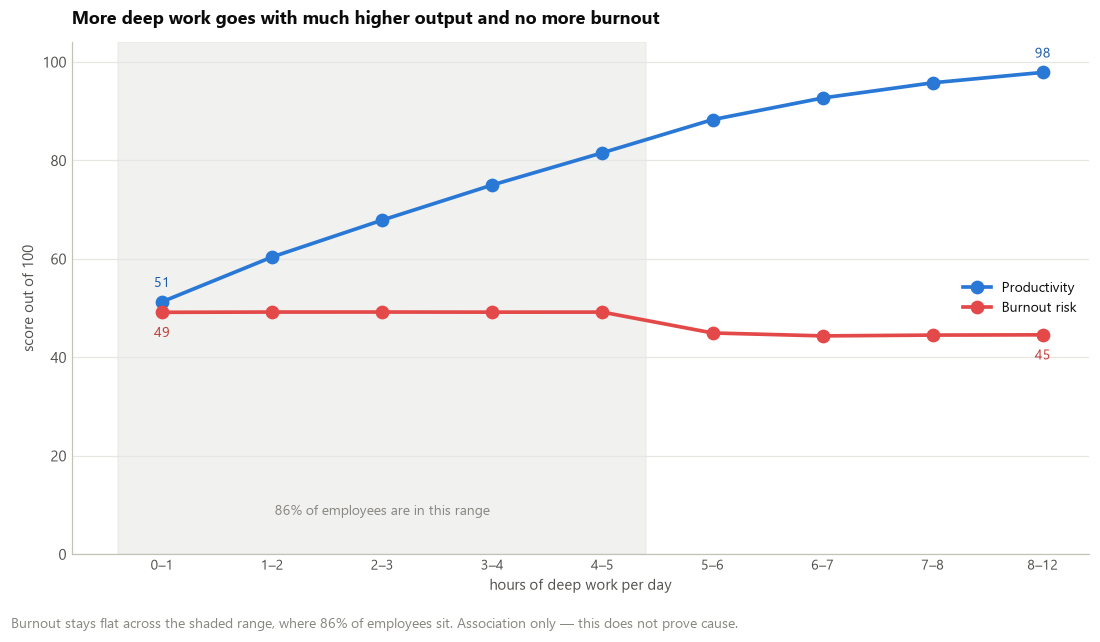

In [25]:
fig, ax = plt.subplots(figsize=(10, 5.6))
x = np.arange(len(dw))
ax.plot(x, dw["productivity"], "o-", color=P.BLUE, lw=2.4, markersize=8, label="Productivity")
ax.plot(x, dw["burnout"], "o-", color=P.RED, lw=2.4, markersize=8, label="Burnout risk")
for i in [0, len(dw) - 1]:
    ax.text(x[i], dw["productivity"].iloc[i] + 3, P.num(dw["productivity"].iloc[i], 0),
            ha="center", fontsize=9, color=P.BETTER)
    ax.text(x[i], dw["burnout"].iloc[i] - 5, P.num(dw["burnout"].iloc[i], 0),
            ha="center", fontsize=9, color=P.WORSE)
ax.set_xticks(x, [f"{int(iv.left)}–{int(iv.right)}" for iv in dw.index], fontsize=9)
below5 = dw.loc[[iv for iv in dw.index if iv.right <= 5], "employees"].sum() / len(model_df) * 100
ax.axvspan(-0.4, 4.4, color=P.GRID, alpha=0.55, zorder=0)
ax.text(2.0, 8, f"{below5:.0f}% of employees are in this range", fontsize=9, color=P.MUTED, ha="center")
ax.set_xlabel("hours of deep work per day")
ax.set_ylabel("score out of 100")
ax.set_ylim(0, 104)
ax.set_title("More deep work goes with much higher output and no more burnout")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="center right")
fig.text(0.005, -0.03, f"Burnout stays flat across the shaded range, where {below5:.0f}% of "
                       f"employees sit. Association only — this does not prove cause.",
         fontsize=9, color=P.MUTED)
fig.tight_layout()
save_fig(fig, "04_deep_work")
plt.show()

## 8. What this analysis can and cannot support

**Supported by the numbers above**

- Three habits — emotional exhaustion, stress, and deep work — account for how the groups differ.
  Fifteen other measured habits are identical across every group.
- Job title, work mode and device type explain none of the variation in either outcome.
- Deep work is associated with substantially higher output and with no increase in burnout.
- One group in ten combines high burnout with above-average output, and is invisible in any report
  that looks only at performance.

**Not supported, and should not be claimed**

- *Cause.* Everything here is association. Nothing shows that reducing someone's stress would
  reduce their burnout.
- *Per-group lifestyle advice.* Groups do not differ on sleep, screen time, exercise or
  scrolling, so advice on those is company-wide, not targeted.
- *Transfer to a real workforce.* The data is synthetic and its inputs are independent by
  construction, which no real workforce is. Re-run this on real HR data before acting.

**Practical limits of the grouping rule**

- It needs three fields per person; anyone missing deep-work hours cannot be placed (2% of the raw
  data).
- The groups are unequal in size (roughly 10% to 15%) because the medians of discrete 1–10 scales
  do not split the population evenly.

## 9. Verification log

The analysis was re-checked in rounds until a round produced no new corrections. Six rounds were
needed. What they found, in order:

| # | Problem found | Effect on the result |
|---|---|---|
| 1 | A 12-group rule was compared against a 7-group clustering and declared better. Eta-squared rises automatically with the number of groups, so the comparison was meaningless. | Conclusion withdrawn and redone at equal group counts. |
| 2 | The replacement comparison used K-Means at k=12, whose stability had never been tested. It turned out to be unstable (ARI 0.62). | The correction itself was unreliable and had to be redone again. |
| 3 | Instability was explained as "the data has no structure". Two models fitted on the full data with different seeds actually agreed at ARI 0.997, so that explanation was wrong. | Explanation replaced with the real mechanism, below. |
| 4 | The real mechanism: with k=7 the eight-cell structure has to merge one cell, and which one gets merged depends on the sample. Two equally good solutions exist (inertia 4.11125 vs 4.11132). | Showed k=7 was the wrong number. |
| 5 | The stability test only varied the random seed, never the data. It was blind to the failure in row 4. | Test criterion rewritten; k=8 then won clearly (0.98 vs 0.62–0.75 for every other k), confirmed by an independent replication. |
| 6 | A coefficient ruled out at section 4.1 as practically negligible was quietly reused later to claim deep work "reduces" burnout, and a headline ratio was built on it. | Claim weakened to what the data supports: deep work does not *increase* burnout. |

A seventh point came out of re-running the finished notebook: the seed-only stability figure for
k=7 was 0.99 in one run and 0.74 in another, purely because a different subset of employees was
drawn. A test whose own answer moves that much between runs cannot settle anything — which is the
same conclusion row 5 reached from a different direction. The chart in section 5.2 now names
whichever k the seed-only test picked *on the run that produced it*, rather than a number written
in by hand.

Also corrected along the way: a single what-if figure was reported for all groups when the
observed values ranged from 18.6 to 21.4; a threshold-dependent count was reported without its
sensitivity; and grid cut points that had been read off the cluster output were presented as an
independent check. All three are fixed in the sections above.

Three earlier statements survived checking unchanged: the independence of the inputs, the flatness
of the fifteen non-defining habits, and the individual-level masking effect of a compensating
risk score.

## 10. From findings to action

Sections 1–9 establish *what is true*. This section turns that into *what to do*, using the
structuring tools a strategy consultancy would apply: a driver decomposition to size the prize, a
MECE issue tree to enumerate causes, fishbone and 5 Whys to reach the root, and an impact/effort
screen to choose actions.

One scoping correction first. The dataset has **no time dimension** — one row per employee, no
dates. So "productivity decline" cannot be analysed; there is nothing to compare across time.
What can be analysed is the **gap**: the distance between productivity now and the level the data
shows is achievable. Everything below is framed that way.

### 10.1 Sizing the gap, and splitting the overlap fairly

The three habits overlap — one person can be on the wrong side of all three — so their effects
cannot simply be added. A **Shapley decomposition** divides each employee's shortfall among
whichever levers are working against them, averaged over every order in which those levers could
be fixed. That is the standard fair-attribution method for overlapping contributions, and here it
has a closed form because the eight groups are a complete 2×2×2 factorial.

In [26]:
from math import factorial

LEVERS = ["exhaustion", "stress", "deep_work"]
LEVER_LABEL = {"exhaustion": "Exhaustion high", "stress": "Stress high", "deep_work": "Deep work low"}

bad = pd.DataFrame({
    "exhaustion": (model_df["grp_exhaustion"] == "HIGH").astype(int),
    "stress":     (model_df["grp_stress"] == "HIGH").astype(int),
    "deep_work":  (model_df["grp_deepwork"] == "LOW").astype(int),
})
cells = (model_df.assign(**bad)
         .groupby(LEVERS)["productivity_score"].agg(["size", "mean"]))
CELL_PROD = {k: v for k, v in cells["mean"].items()}   # not `P` — that is the plotting module
best_cell = CELL_PROD[(0, 0, 0)]
mean_now = model_df["productivity_score"].mean()

print(f"Productivity now                        : {mean_now:.2f} / 100")
print(f"Best group (all three levers favourable): {best_cell:.2f} / 100"
      f"  ({cells['size'][(0,0,0)]/len(model_df)*100:.1f}% of staff)")
print(f"GAP                                     : {best_cell - mean_now:.2f} points\n")

n_bad = bad.sum(axis=1)
print("How many levers work against each person:")
for k, grp in model_df.groupby(n_bad.values):
    print(f"  {k} lever(s) unfavourable: {len(grp)/len(model_df)*100:5.1f}% of staff"
          f"   ·   productivity {grp['productivity_score'].mean():.1f}")

def fixed_value(cell, fix):
    """Productivity for this cell once the levers in `fix` are moved to the favourable side."""
    state = list(cell)
    for i in fix:
        state[i] = 0
    return CELL_PROD[tuple(state)]

shapley = np.zeros(3)
gap_total = 0.0
for cell, row in cells.iterrows():
    weight = row["size"] / len(model_df)
    gap_total += weight * (best_cell - row["mean"])
    against = [i for i, x in enumerate(cell) if x == 1]
    m = len(against)
    for i in against:
        others = [j for j in against if j != i]
        phi = 0.0
        for t in range(len(others) + 1):
            for subset in itertools.combinations(others, t):
                w = factorial(t) * factorial(m - t - 1) / factorial(m)
                phi += w * (fixed_value(cell, set(subset) | {i}) - fixed_value(cell, set(subset)))
        shapley[i] += weight * phi

gap = pd.DataFrame({
    "lever": [LEVER_LABEL[l] for l in LEVERS],
    "points_of_gap": shapley,
    "share_of_gap_pct": shapley / gap_total * 100,
    "staff_affected_pct": [bad[l].mean() * 100 for l in LEVERS],
}).sort_values("points_of_gap", ascending=False)
print("\n" + gap.round(2).to_string(index=False))
print(f"\nSum of the three: {shapley.sum():.2f} points — reconciles with the {gap_total:.2f}-point gap.")
gap.to_csv(TAB / "08_gap_decomposition.csv", index=False)

Productivity now                        : 71.45 / 100
Best group (all three levers favourable): 86.14 / 100  (14.7% of staff)
GAP                                     : 14.69 points



How many levers work against each person:


  0 lever(s) unfavourable:  14.7% of staff   ·   productivity 86.1
  1 lever(s) unfavourable:  39.7% of staff   ·   productivity 76.0
  2 lever(s) unfavourable:  35.3% of staff   ·   productivity 65.2
  3 lever(s) unfavourable:  10.2% of staff   ·   productivity 54.3

          lever  points_of_gap  share_of_gap_pct  staff_affected_pct
  Deep work low           9.85             67.08               51.11
Exhaustion high           2.51             17.10               40.01
    Stress high           2.33             15.83               49.99

Sum of the three: 14.69 points — reconciles with the 14.69-point gap.


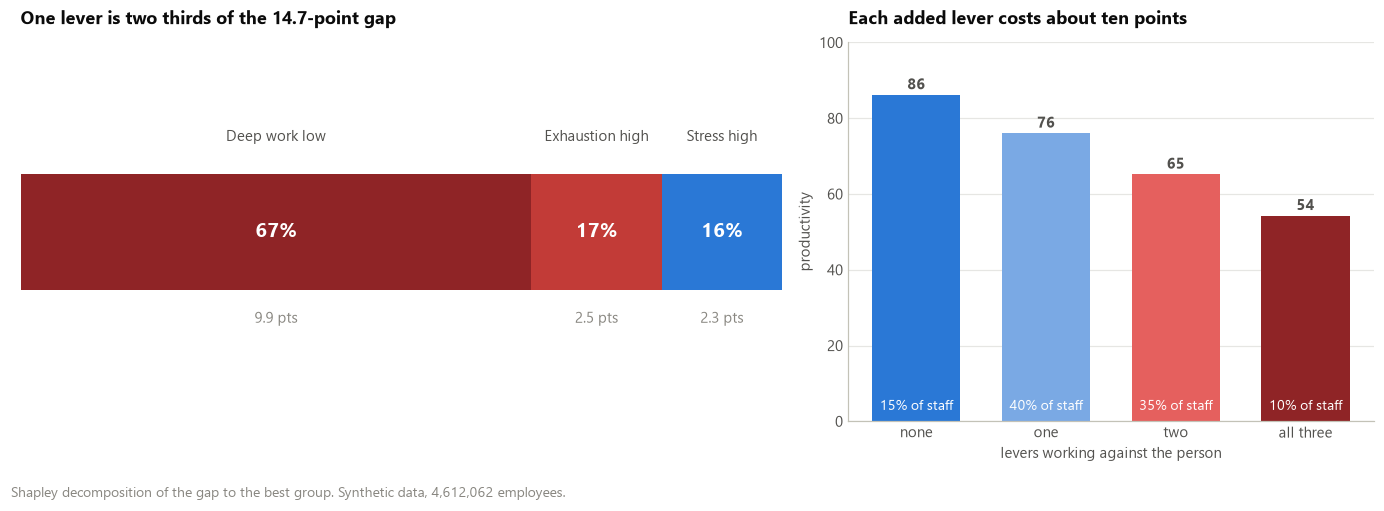

In [27]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.6, 4.4),
                               gridspec_kw={"width_ratios": [1.45, 1]})

left = 0
for (_, r), c in zip(gap.iterrows(), ["#8f2426", "#c23b37", "#2a78d6"]):
    axL.barh(0, r["share_of_gap_pct"], left=left, height=.46, color=c)
    if r["share_of_gap_pct"] > 8:
        axL.text(left + r["share_of_gap_pct"]/2, 0, f"{r['share_of_gap_pct']:.0f}%",
                 ha="center", va="center", color="#fff", fontsize=13, fontweight="bold")
        axL.text(left + r["share_of_gap_pct"]/2, .36, r["lever"], ha="center", fontsize=10,
                 color=P.INK_2)
        axL.text(left + r["share_of_gap_pct"]/2, -.36, f"{r['points_of_gap']:.1f} pts",
                 ha="center", fontsize=9.5, color=P.MUTED)
    else:
        axL.text(left + r["share_of_gap_pct"]/2, 0, f"{r['share_of_gap_pct']:.0f}%",
                 ha="center", va="center", color="#fff", fontsize=11, fontweight="bold")
        axL.text(left + r["share_of_gap_pct"]/2, .36, r["lever"].replace(" ", "\n"),
                 ha="center", fontsize=9, color=P.INK_2)
    left += r["share_of_gap_pct"]
axL.set_xlim(0, 100); axL.set_ylim(-.75, .75); axL.axis("off")
axL.set_title(f"One lever is two thirds of the {gap_total:.1f}-point gap")

counts = [(model_df["productivity_score"][n_bad.values == k].mean(),
           (n_bad.values == k).mean() * 100) for k in range(4)]
ys = [c[0] for c in counts]; ws = [c[1] for c in counts]
bars = axR.bar(range(4), ys, color=[P.BLUE, "#7aa9e4", "#e5605e", "#8f2426"], width=.68)
for i, (yv, wv) in enumerate(zip(ys, ws)):
    axR.text(i, yv + 1.5, f"{yv:.0f}", ha="center", fontsize=10, fontweight="bold", color=P.INK_2)
    axR.text(i, 3, f"{wv:.0f}% of staff", ha="center", fontsize=9, color="#fff")
axR.set_xticks(range(4), ["none", "one", "two", "all three"], fontsize=9.5)
axR.set_xlabel("levers working against the person")
axR.set_ylabel("productivity")
axR.set_ylim(0, 100); axR.grid(axis="y"); axR.set_axisbelow(True)
axR.set_title("Each added lever costs about ten points")
fig.text(0.005, -0.04, "Shapley decomposition of the gap to the best group. "
                       f"Synthetic data, {len(model_df):,} employees.", fontsize=9, color=P.MUTED)
fig.tight_layout()
save_fig(fig, "05_gap_decomposition")
plt.show()

### 10.2 Can this data explain the biggest lever?

Deep work is where the gap is. The obvious next question is why half the workforce is below the
median on it — so the same regression machinery is turned on that question.

In [28]:
others = [c for c in PRED if c != "deep_work_hours"]
dw_model = sm.OLS(model_df["deep_work_hours"].astype("float64"),
                  sm.add_constant(model_df[others].astype("float64"))).fit()
print(f"Explaining deep-work hours from the other 24 habits:  R² = {dw_model.rsquared:.5f}\n")

hypotheses = {
    "meeting_hours": "Meetings crowd out deep work",
    "notification_count": "Notifications interrupt",
    "app_switch_frequency": "Constant app switching",
    "distraction_frequency": "Frequent interruptions",
    "remote_work_days": "Amount of remote work",
    "workspace_quality": "Poor workspace",
    "sleep_hours": "Too little sleep",
    "motivation_level": "Low motivation",
}
checks = pd.DataFrame([
    {"hypothesis": label, "r_with_deep_work": model_df[col].corr(model_df["deep_work_hours"])}
    for col, label in hypotheses.items()])
checks["verdict"] = np.where(checks["r_with_deep_work"].abs() < 0.02,
                             "no signal in this data", "worth pursuing")
print(checks.round(4).to_string(index=False))
checks.to_csv(TAB / "09_deep_work_hypotheses.csv", index=False)

spread_dw = ((model_df[model_df["grp_deepwork"] == "HIGH"][others].mean() -
              model_df[model_df["grp_deepwork"] == "LOW"][others].mean()).abs()
             / model_df[others].std()).max()
print(f"\nLargest difference between high- and low-deep-work employees on any other habit: "
      f"{spread_dw:.4f} standard deviations.")

Explaining deep-work hours from the other 24 habits:  R² = 0.00000



                  hypothesis  r_with_deep_work                verdict
Meetings crowd out deep work           -0.0005 no signal in this data
     Notifications interrupt            0.0005 no signal in this data
      Constant app switching            0.0004 no signal in this data
      Frequent interruptions           -0.0003 no signal in this data
       Amount of remote work           -0.0004 no signal in this data
              Poor workspace            0.0001 no signal in this data
            Too little sleep            0.0000 no signal in this data
              Low motivation            0.0000 no signal in this data



Largest difference between high- and low-deep-work employees on any other habit: 0.0025 standard deviations.


**This is the most consequential result in the section.** The dataset locates the biggest lever
and is then structurally unable to explain it: R² is zero to five decimal places, and every
common explanation — meetings, notifications, workspace, sleep, motivation — sits at r ≈ 0.000.
More analysis of *this* dataset will never answer why.

A caveat on how far that travels. These variables were generated independently of each other, so
"no signal" here is a property of the simulation, not evidence about a real workforce. The honest
label is **untested**, not *disproved*. Either way the implication is the same: the next step is
to **measure**, not to analyse further.

### 10.3 Issue tree — why is deep work low?

Four branches, mutually exclusive and collectively exhaustive, with what this dataset can say
about each:

| Branch | Meaning | Evidence status |
|---|---|---|
| **B1 · No time available** | The calendar is consumed by meetings and reactive work | Untested — meeting hours exist in the data but are independent of everything by construction |
| **B2 · Time exists but is fragmented** | Enough total free time, no block long enough to use | **No data** — the dataset measures total hours, never block length |
| **B3 · Blocks exist but are not used for deep work** | Habit, environment, expectation of instant reply | No data |
| **B4 · The role does not call for deep work** | Job design, share of reactive work | No data — occupation explains nothing (eta² = 0) |

**B2 is where the blind spot bites hardest.** Total available hours and longest contiguous block
are different quantities, and only the first is measured. A workforce could have ample free time
and still be unable to do deep work.

### 10.4 Fishbone and 5 Whys

Six directions scanned for causes of low deep work: **method** (default meeting lengths, no
focus-block convention) · **machine** (notifications on by default, synchronous chat) ·
**people** (day-planning skill, message-checking habit) · **measurement** (nobody measures deep
work; performance is judged on output and responsiveness) · **environment** (expected reply
times, open-plan space) · **inputs** (unclear briefs that prevent starting).

Five Whys down the largest branch:

1. *Why is productivity 14.7 points below what is achievable?* Half the workforce is below the
   deep-work median, and that accounts for two thirds of the gap.
2. *Why is their deep work low?* Unknown — the data cannot say.
3. *Why is it unknown?* Deep work is not measured; the only trace of it is a self-reported score
   with no time or context attached.
4. *Why is it not measured?* Performance systems count output and responsiveness, not the
   conditions that produce output.
5. *Why do they count only those?* Output is easy to count, and no one owns focus time.

**Root cause, at the system level: there is no measure of focus time and no owner for it.** So it
is never managed, and no intervention can tell whether it worked.

### 10.5 Actions, screened on impact and effort

Because the data cannot identify causes, each action is designed to **carry its own measurement** —
intervening and gathering evidence in the same move.

| # | Action | Impact | Effort | Verdict |
|---|---|---|---|---|
| 1 | **Measure deep work.** Existing tools (calendar, IDE, chat status) report blocks of 90+ minutes per person per week | None directly — but unlocks everything else | Low | **Do now** |
| 2 | **Protected focus blocks.** Two meeting-free mornings a week, unit-wide | Most of the 9.9 points, if B1 or B2 holds | Low | **Do now** |
| 3 | **Response-time convention.** State which channel expects an answer in what time | Addresses B3 | Low | **Do now** |
| 4 | Default meetings to 25/50 minutes, agenda required | Addresses B1 | Medium | Next |
| 5 | **Controlled pilot.** Two units run actions 2+3, two do not, measured for 8 weeks | Produces the causal evidence this analysis cannot | Medium | **High priority** |
| 6 | Review job design for the 10% facing all three levers | 54 → plausibly 65–76 | High | Later |
| 7 | Workload and autonomy work on exhaustion and stress | 4.8 points combined | High | Later |

Action 1 ranks above everything despite producing no points by itself: without it, no other action
can be shown to work — which is exactly the root cause the 5 Whys reached.

### 10.6 Sequencing, ownership and measurement

| Horizon | When | What | Gate to the next horizon |
|---|---|---|---|
| **H1** | Weeks 1–4 | Actions 1, 2, 3 in two pilot units | Baseline deep-work figure for 80%+ of staff |
| **H2** | Weeks 5–12 | Controlled pilot (action 5), add action 4 | Deep work up ≥0.5 h/day in pilot units versus control |
| **H3** | Quarter 2+ | Actions 6 and 7, then scale | H2 positive and reproduced |

**Decision rights.** Recommend: analytics. Agree: pilot unit heads, who hold the veto over their
own calendars. Perform: line managers. Input: HR and IT. Decide: **a single named owner of the
focus-time metric** — a role that does not currently exist, which is the root cause restated as an
org-design gap.

**Metrics.** Deep-work hours per person per week (leading) · productivity score (lagging) ·
burnout score (**guardrail** — if deep work rises and burnout rises with it, stop, regardless of
what section 3 of this notebook found).

### 10.7 What to tell leadership

This analysis narrows the field from twenty-five habits to one, and sizes it: deep work is two
thirds of a 14.7-point gap and touches half the workforce. It does **not** establish cause, and on
this dataset it cannot. The right next step is a controlled pilot with measurement attached — not
another round of analysis.

In [29]:
print("Artefacts written:")
for path in sorted(TAB.glob("*.csv")):
    print(f"  tables/{path.name}")
for path in sorted(FIG.glob("*.png")):
    print(f"  figures/{path.name}")
print(f"\nEmployees analysed: {len(model_df):,}")
print(f"Groups: {model_df['segment'].nunique()}   "
      f"Highest-priority group: {segments.index[0]} ({segments.iloc[0]['share_pct']:.1f}% of staff)")

Artefacts written:
  tables/01_context_anova.csv
  tables/02_drivers.csv
  tables/03_k_selection.csv
  tables/04_habit_spread.csv
  tables/05_method_comparison.csv
  tables/06_segments.csv
  tables/07_observed_differences.csv
  tables/08_gap_decomposition.csv
  tables/09_deep_work_hypotheses.csv
  figures/01_drivers.png
  figures/02_k_selection.png
  figures/03_segments.png
  figures/04_deep_work.png
  figures/05_gap_decomposition.png

Employees analysed: 4,612,062
Groups: 8   Highest-priority group: Exhaustion HIGH / Stress HIGH / Deep work LOW (10.2% of staff)
